In [1]:
import pandas as pd
import csv

In [2]:
df=pd.read_csv("laptop_price.csv",encoding="latin-1")

In [3]:
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [4]:
df.isnull().sum()
df.dropna(inplace=True)


In [5]:
df=df.drop("Product",axis=1)

In [6]:
df = df.join(pd.get_dummies(df.Company, dtype=int))
df= df.drop("Company",axis=1)

In [7]:
df=df.join(pd.get_dummies(df.TypeName, dtype=int))
df=df.drop("TypeName",axis=1)

In [8]:
df["ScreenResolution"]=df.ScreenResolution.str.split(" ").apply(lambda x: x[-1])
df["Screen Width"]=df.ScreenResolution.str.split("x").apply(lambda x: x[0])
df["Screen Height"]=df.ScreenResolution.str.split("x").apply(lambda x: x[1])
df=df.drop("ScreenResolution",axis=1)

In [9]:
df["CPU Brand"]=df.Cpu.str.split(" ").apply(lambda x: x[0])
df["CPU Frequency"]=df.Cpu.str.split(" ").apply(lambda x: x[-1])

In [10]:
df["CPU Frequency"]=df["CPU Frequency"].str[:-3]
df=df.drop("Cpu",axis=1)

In [11]:
df["Ram"]=df["Ram"].str[:-2]
df["Ram"]=df["Ram"].astype(int)
df["CPU Frequency"]=df["CPU Frequency"].astype(float)
df["Screen Height"]=df["Screen Height"].astype(int)
df["Screen Width"]=df["Screen Width"].astype(int)

In [12]:
df["Memory Amount"]=df.Memory.str.split(" ").apply(lambda x:x[0])
df["Memory Type"]=df.Memory.str.split(" ").apply(lambda x:x[1])

In [13]:
def turn_memory_into_MB(value):
    if "GB" in value:
        return float(value[:value.find("GB")])*1000
    elif "TB" in value:
        return float(value[:value.find("TB")])*1000000

In [14]:
df["Memory Amount"]=df["Memory Amount"].apply(turn_memory_into_MB)
df=df.drop("Memory",axis=1)

In [15]:
df["Weight"]=df["Weight"].str[:-2]

In [16]:
df["Weight"]=df["Weight"].astype("float")

In [17]:
df["GPU Brand"]=df.Gpu.str.split(" ").apply(lambda x: x[0])
df=df.drop("Gpu",axis=1)

In [18]:
df=df.join(pd.get_dummies(df.OpSys, dtype=int))
df=df.drop("OpSys",axis=1)

In [19]:
cpu_categories = pd.get_dummies(df["CPU Brand"], dtype=int)
cpu_categories.columns = [col + "_CPU" for col in cpu_categories.columns]

df = df.join(cpu_categories)
df = df.drop("CPU Brand", axis=1)


In [20]:
gpu_categories=pd.get_dummies(df["GPU Brand"], dtype=int)
gpu_categories.columns=[col + "_GPU" for col in gpu_categories.columns]

df=df.join(gpu_categories)
df=df.drop("GPU Brand",axis=1)

In [21]:
memory_categories = pd.get_dummies(df["Memory Type"], dtype=int)
memory_categories.columns = [col + "_Memory" for col in memory_categories.columns]

df = df.join(memory_categories)
df = df.drop("Memory Type", axis=1)

In [22]:
df["Price_Rupees*100"]=df["Price_euros"]
df=df.drop("Price_euros",axis=1)

In [23]:
df

,laptop_ID,Inches,Ram,Weight,Acer,Apple,Asus,Chuwi,Dell,Fujitsu,...,Samsung_CPU,AMD_GPU,ARM_GPU,Intel_GPU,Nvidia_GPU,Flash_Memory,HDD_Memory,Hybrid_Memory,SSD_Memory,Price_Rupees*100
0,1,13.3,8,1.37,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1339.69
1,2,13.3,8,1.34,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,898.94
2,3,15.6,8,1.86,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,575.00
3,4,15.4,16,1.83,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,2537.45
4,5,13.3,8,1.37,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,14.0,4,1.80,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,638.00
1299,1317,13.3,16,1.30,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1499.00
1300,1318,14.0,2,1.50,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,229.00
1301,1319,15.6,6,2.19,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,764.00


In [24]:
import random

def generate_synthetic_rows(df, n_rows=1000):
    new_rows = []

    for _ in range(n_rows):
        base = df.sample(1).iloc[0].copy()

        # Vary RAM slightly (but keep within valid range)
        if 'Ram' in base:
            base['Ram'] = min(128, max(2, base['Ram'] + random.choice([-2, 0, 2])))

        # Vary CPU Frequency
        if 'CPU Frequency' in base:
            base['CPU Frequency'] = round(base['CPU Frequency'] + random.uniform(-0.3, 0.3), 2)
            base['CPU Frequency'] = max(0.5, min(base['CPU Frequency'], 5.5))

        # Vary Screen Size
        if 'Screen Width' in base and 'Screen Height' in base:
            base['Screen Width'] += random.randint(-100, 100)
            base['Screen Height'] += random.randint(-50, 50)

        # Vary Memory Amount
        if 'Memory Amount' in base:
            base['Memory Amount'] *= random.choice([0.9, 1.0, 1.1])

        # Vary Weight
        if 'Weight' in base:
            base['Weight'] += round(random.uniform(-0.3, 0.3), 2)
            base['Weight'] = max(0.5, min(base['Weight'], 5.0))

        # Add noise to price
        if 'Price_Rupees*100' in base:
            base['Price_Rupees*100'] *= random.uniform(0.95, 1.05)

        new_rows.append(base)

    synthetic_df = pd.DataFrame(new_rows)
    return pd.concat([df, synthetic_df], ignore_index=True)


In [25]:
df_augmented = generate_synthetic_rows(df, n_rows=1000)
print(f"Original dataset: {df.shape[0]} rows")
print(f"Augmented dataset: {df_augmented.shape[0]} rows")


Original dataset: 1303 rows
Augmented dataset: 2303 rows


In [26]:
df_augmented

,laptop_ID,Inches,Ram,Weight,Acer,Apple,Asus,Chuwi,Dell,Fujitsu,...,Samsung_CPU,AMD_GPU,ARM_GPU,Intel_GPU,Nvidia_GPU,Flash_Memory,HDD_Memory,Hybrid_Memory,SSD_Memory,Price_Rupees*100
0,1.0,13.3,8.0,1.37,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1339.690000
1,2.0,13.3,8.0,1.34,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,898.940000
2,3.0,15.6,8.0,1.86,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,575.000000
3,4.0,15.4,16.0,1.83,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2537.450000
4,5.0,13.3,8.0,1.37,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1803.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2298,1009.0,13.3,8.0,1.67,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1184.252700
2299,728.0,14.0,8.0,1.18,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1716.066106
2300,236.0,15.6,6.0,1.99,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,317.322549
2301,410.0,15.6,8.0,2.63,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,856.802427


<Axes: >

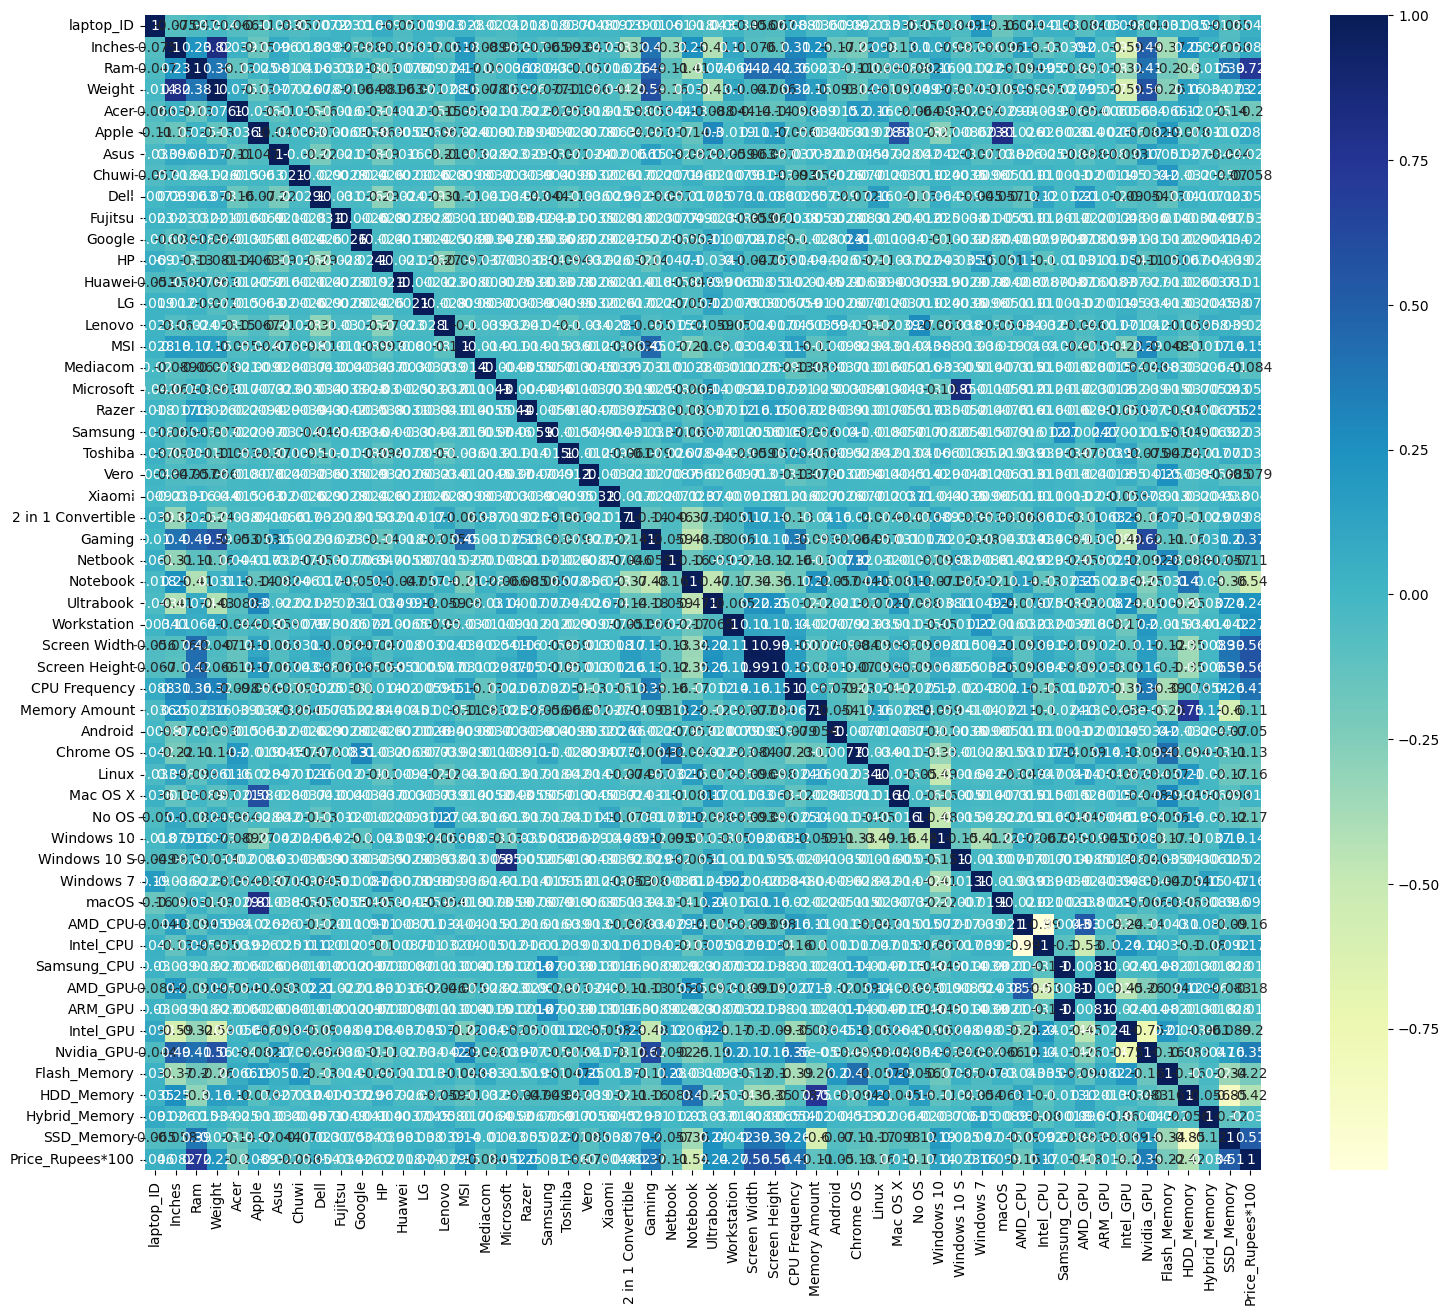

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,15))
sns.heatmap(df_augmented.corr(),annot=True,cmap="YlGnBu")

In [28]:
target_correlations=df_augmented.corr()['Price_Rupees*100'].apply(abs).sort_values()
target_correlations

Xiaomi                0.004418
Samsung_CPU           0.013646
ARM_GPU               0.013646
Mac OS X              0.014085
Huawei                0.018255
Asus                  0.021846
Windows 10 S          0.023080
Google                0.025665
HP                    0.027388
Lenovo                0.029013
Samsung               0.031247
Fujitsu               0.033833
Hybrid_Memory         0.033840
Toshiba               0.036485
laptop_ID             0.046222
Android               0.049567
Microsoft             0.051903
Dell                  0.053721
Chuwi                 0.058147
LG                    0.074185
Vero                  0.079226
2 in 1 Convertible    0.081553
Inches                0.082027
Mediacom              0.084162
Apple                 0.088831
macOS                 0.099094
Netbook               0.107138
Memory Amount         0.114269
Chrome OS             0.131548
Windows 10            0.135683
MSI                   0.153794
Windows 7             0.161770
Linux   

In [29]:
selected_features=target_correlations[-29:].index
selected_features=list(selected_features)
selected_features

['macOS',
 'Netbook',
 'Memory Amount',
 'Chrome OS',
 'Windows 10',
 'MSI',
 'Windows 7',
 'Linux',
 'AMD_CPU',
 'Intel_CPU',
 'No OS',
 'AMD_GPU',
 'Intel_GPU',
 'Acer',
 'Weight',
 'Flash_Memory',
 'Ultrabook',
 'Razer',
 'Workstation',
 'Nvidia_GPU',
 'Gaming',
 'CPU Frequency',
 'HDD_Memory',
 'SSD_Memory',
 'Notebook',
 'Screen Height',
 'Screen Width',
 'Ram',
 'Price_Rupees*100']

In [30]:
limited_df=df_augmented[selected_features]
limited_df

,macOS,Netbook,Memory Amount,Chrome OS,Windows 10,MSI,Windows 7,Linux,AMD_CPU,Intel_CPU,...,Nvidia_GPU,Gaming,CPU Frequency,HDD_Memory,SSD_Memory,Notebook,Screen Height,Screen Width,Ram,Price_Rupees*100
0,1.0,0.0,128000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,2.30,0.0,1.0,0.0,1600.0,2560.0,8.0,1339.690000
1,1.0,0.0,128000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.80,0.0,0.0,0.0,900.0,1440.0,8.0,898.940000
2,0.0,0.0,256000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,2.50,0.0,1.0,1.0,1080.0,1920.0,8.0,575.000000
3,1.0,0.0,512000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,2.70,0.0,1.0,0.0,1800.0,2880.0,16.0,2537.450000
4,1.0,0.0,256000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,3.10,0.0,1.0,0.0,1600.0,2560.0,8.0,1803.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2298,0.0,0.0,230400.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,2.59,0.0,1.0,1.0,1801.0,3246.0,8.0,1184.252700
2299,0.0,0.0,563200.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,2.53,0.0,1.0,0.0,1468.0,2609.0,8.0,1716.066106
2300,0.0,0.0,450000.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.67,1.0,0.0,1.0,756.0,1364.0,6.0,317.322549
2301,0.0,0.0,256000.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.82,0.0,1.0,1.0,1091.0,1963.0,8.0,856.802427


<Axes: >

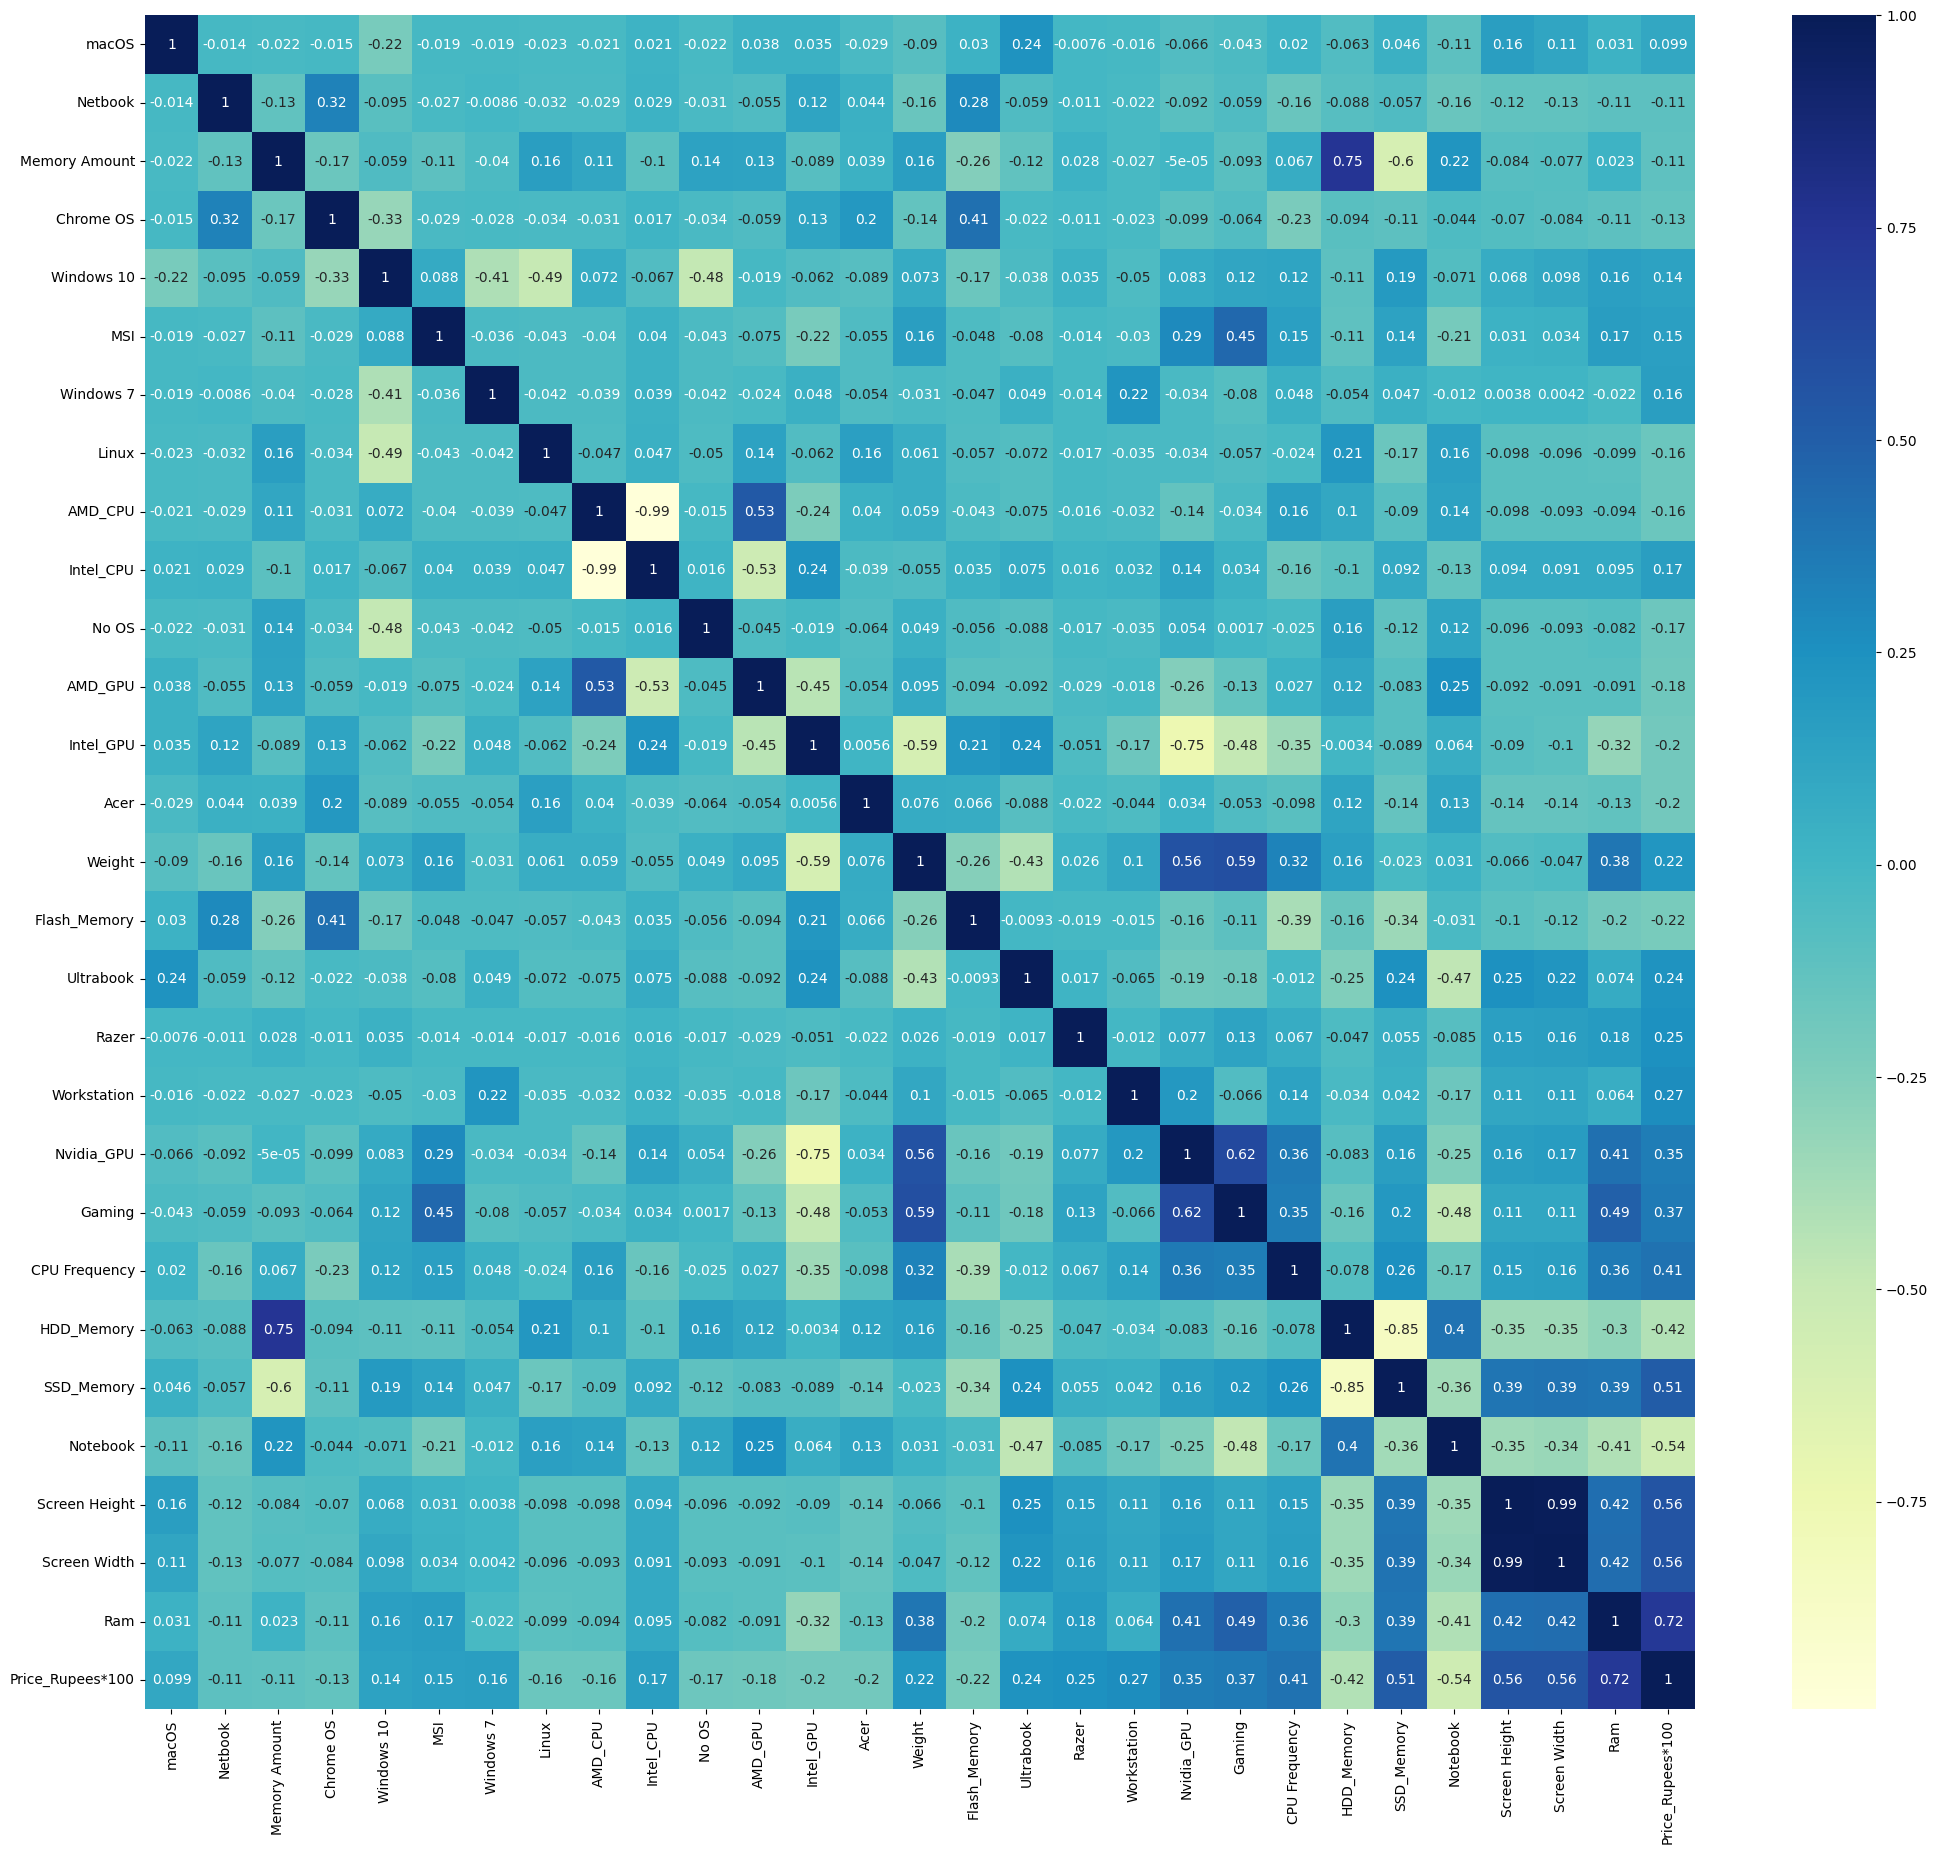

In [31]:
plt.figure(figsize=(25,22))
sns.heatmap(limited_df.corr(),annot=True,cmap="YlGnBu")

In [32]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [33]:
X = limited_df.drop("Price_Rupees*100", axis=1)
y = limited_df["Price_Rupees*100"]

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [35]:
# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [36]:
# 2. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# 3. Initialize and train XGBoost model
xgb_model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'  # Important for regression
)
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
# 4. Predict on test set
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [39]:
# 5. Evaluate performance
print("\n🔹 XGBoost Metrics:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_xgb):.4f}")


🔹 XGBoost Metrics:
MAE: 198.53
MSE: 96010.52
RMSE: 309.86
R2 Score: 0.8189


In [40]:
# 6. Predict on a single sample
X_new_scaled = scaler.transform([X_test.iloc[0]])  # Use the same scaler
predicted_price_xgb = xgb_model.predict(X_new_scaled)[0]
actual_price = y_test.iloc[0]

print(f"Predicted Price (XGBoost): ₹{predicted_price_xgb*100:.2f}")
print(f"Actual Price: ₹{actual_price*100:.2f}")

Predicted Price (XGBoost): ₹56686.29
Actual Price: ₹53000.00


C:\Users\yash\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [41]:
# # Define the neural network model
# nn_model = keras.Sequential([
#     layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
#     layers.Dense(32, activation='relu'),
#     layers.Dense(1)
# ])

# # Compile the model
# nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# # Train the model
# history=nn_model.fit(
#     X_train_scaled, y_train,
#     validation_data=(X_test_scaled, y_test),
#     epochs=35,
#     batch_size=32,
#     verbose=1
# )


In [42]:
# # 🔮 Neural Network Predictions
# nn_preds = nn_model.predict(X_test_scaled).flatten()

# # 📊 Neural Network Scatter Plot
# plt.figure(figsize=(12, 8))
# plt.scatter(nn_preds, y_test, alpha=0.5)
# plt.plot(range(int(y_test.min()), int(y_test.max())), range(int(y_test.min()), int(y_test.max())), c="green")
# plt.title("Neural Network Predictions vs Actual")
# plt.xlabel("Predicted Price")    
# plt.ylabel("Actual Price")
# plt.grid(True)
# plt.show()


In [43]:
# plt.figure(figsize=(10, 5))
# plt.plot(history.history['mae'], label='Train MAE')
# plt.plot(history.history['val_mae'], label='Validation MAE')
# plt.title("Neural Network MAE per Epoch")
# plt.xlabel("Epoch")
# plt.ylabel("Mean Absolute Error")
# plt.legend()
# plt.grid(True)
# plt.show()


In [44]:
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

def get_valid_input(prompt, dtype, choices=None, value_range=None):
    while True:
        try:
            user_input = dtype(input(prompt))
            if choices and user_input not in choices:
                print(f"Invalid choice. Choose from: {choices}")
                continue
            if value_range and not (value_range[0] <= user_input <= value_range[1]):
                print(f"Value out of range. Enter between {value_range[0]} and {value_range[1]}")
                continue
            return user_input
        except:
            print(f"Invalid input. Expected {dtype.__name__}")

def prepare_user_input():
    print("📥 Enter Laptop Configuration to Predict Price:\n")

    ram = get_valid_input("Enter RAM size (in GB): ", int, value_range=(2, 128))
    cpu_freq = get_valid_input("Enter CPU Frequency (in GHz): ", float, value_range=(0.5, 5.5))
    screen_width = get_valid_input("Enter Screen Width (in px): ", int, value_range=(600, 6000))
    screen_height = get_valid_input("Enter Screen Height (in px): ", int, value_range=(400, 4000))
    weight = get_valid_input("Enter Laptop Weight (in kg): ", float, value_range=(0.5, 5.0))
    memory_amount = get_valid_input("Enter Memory Amount (in MB): ", float, value_range=(128, 2000000))

    print("\nChoose from the following one-hot categories:")
    print(f"🔹 CPU: {', '.join([col.replace('_CPU','') for col in X.columns if '_CPU' in col])}")
    cpu_brand = get_valid_input("Enter CPU Brand exactly as shown above: ", str,
                                choices=[col.replace('_CPU','') for col in X.columns if '_CPU' in col])

    print(f"\n🔹 GPU: {', '.join([col.replace('_GPU','') for col in X.columns if '_GPU' in col])}")
    gpu_brand = get_valid_input("Enter GPU Brand exactly as shown above: ", str,
                                choices=[col.replace('_GPU','') for col in X.columns if '_GPU' in col])

    print(f"\n🔹 OS: {', '.join([col for col in X.columns if col in ['Windows 10', 'Mac OS X', 'Linux', 'No OS', 'Windows 7']])}")
    opsys = get_valid_input("Enter OS exactly as shown above: ", str,
                            choices=[col for col in X.columns if col in ['Windows 10', 'Mac OS X', 'Linux', 'No OS', 'Windows 7']])

    print(f"\n🔹 Memory Type: {', '.join([col.replace('_Memory','') for col in X.columns if '_Memory' in col])}")
    memory_type = get_valid_input("Enter Memory Type exactly as shown above: ", str,
                                  choices=[col.replace('_Memory','') for col in X.columns if '_Memory' in col])

    user_row = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)

    user_row.at[0, 'Ram'] = ram
    user_row.at[0, 'CPU Frequency'] = cpu_freq
    user_row.at[0, 'Screen Width'] = screen_width
    user_row.at[0, 'Screen Height'] = screen_height
    user_row.at[0, 'Weight'] = weight
    user_row.at[0, 'Memory Amount'] = memory_amount

    user_row.at[0, f"{cpu_brand}_CPU"] = 1
    user_row.at[0, f"{gpu_brand}_GPU"] = 1
    user_row.at[0, f"{opsys}"] = 1
    user_row.at[0, f"{memory_type}_Memory"] = 1

    return user_row

# Prepare input
user_input_df = prepare_user_input()

# Scale input using fitted scaler
user_input_scaled = scaler.transform(user_input_df)

# Predict using XGBoost model
pred_xgb = xgb_model.predict(user_input_scaled)[0]

# Display result
print("\n🎯 Prediction Results (Using XGBoost):")
print(f"🔹 Predicted Laptop Price: ₹{pred_xgb*10:.2f}")


📥 Enter Laptop Configuration to Predict Price:


Choose from the following one-hot categories:
🔹 CPU: AMD, Intel

🔹 GPU: AMD, Intel, Nvidia

🔹 OS: Windows 10, Windows 7, Linux, No OS
Invalid choice. Choose from: ['Windows 10', 'Windows 7', 'Linux', 'No OS']

🔹 Memory Type: Flash, HDD, SSD

🎯 Prediction Results (Using XGBoost):
🔹 Predicted Laptop Price: ₹18098.13


In [45]:
import joblib
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']